**PROJECT 1: Linear Regression**

Epoch 0: Loss = 41.054939
Epoch 50: Loss = 0.462141
Epoch 100: Loss = 0.304091
Epoch 150: Loss = 0.282212
Epoch 200: Loss = 0.279183
Epoch 250: Loss = 0.278764
Epoch 300: Loss = 0.278705
Epoch 350: Loss = 0.278697
Epoch 400: Loss = 0.278696
Epoch 450: Loss = 0.278696

Final parameters: w = 2.5107, b = 1.0114
True parameters: w = 2.5, b = 1.0


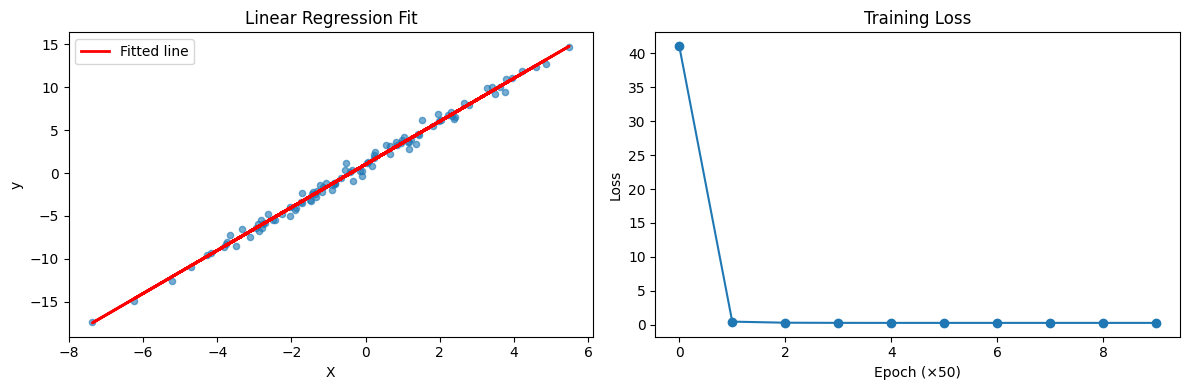

In [7]:
import jax
import jax.numpy as jnp
from jax import grad, jit, value_and_grad
import matplotlib.pyplot as plt

# 1. Generate synthetic data
key = jax.random.PRNGKey(42)
key, subkey = jax.random.split(key)

X_train = jax.random.normal(subkey, (100, 1)) * 3
y_train = 2.5 * X_train + 1.0 + jax.random.normal(jax.random.split(key)[1], (100, 1)) * 0.5

# 2. Define model and loss
def predict(params, x):
    w, b = params
    return w * x + b

def loss_fn(params, x, y):
    y_pred = predict(params, x)
    return jnp.mean((y_pred - y)**2)

# 3. Initialize parameters
params = (jnp.array(0.0), jnp.array(0.0))

# 4. JIT-compiled training step
@jit
def train_step(params, x, y, learning_rate):
    loss, grads = value_and_grad(loss_fn)(params, x, y)
    w_grad, b_grad = grads
    w, b = params

    new_params = (
        w - learning_rate * w_grad,
        b - learning_rate * b_grad
    )
    return new_params, loss

# 5. Training loop
learning_rate = 0.01
losses = []

for epoch in range(500):
    params, loss = train_step(params, X_train, y_train, learning_rate)
    if epoch % 50 == 0:
        losses.append(float(loss))
        print(f"Epoch {epoch}: Loss = {loss:.6f}")

# 6. Results
w_final, b_final = params
print(f"\nFinal parameters: w = {float(w_final):.4f}, b = {float(b_final):.4f}")
print(f"True parameters: w = 2.5, b = 1.0")

# 7. Visualization
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(X_train, y_train, alpha=0.6, s=20)
plt.plot(X_train, predict(params, X_train), 'r-', lw=2, label='Fitted line')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.title('Linear Regression Fit')

plt.subplot(1, 2, 2)
plt.plot(losses, marker='o')
plt.xlabel('Epoch (×50)')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.tight_layout()
plt.savefig('linear_regression_results.png')
plt.show()